In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from models import build_MalBERT
import polars as pl
from tqdm.notebook import tqdm

from typing import List
from collections import defaultdict
import re

E0000 00:00:1741896477.635821   82225 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741896477.642154   82225 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
MODEL_WEIGHTS = os.path.join("models", "malbert-model.keras")
MANIFESTS_FILEPATH = "manifests"
APPLICATION_LIST = "master-list"

#Maximum number of files for analysis
ANALIZED_FILES = 1000

#number of random obfuscations to apply for each file
RANDOM_SAMPLES = 100

#A minimum acceptable difference between originaland obfuscated predictions
SIGNIFICANT_DIFF = 0.9

#We consider only those cases for which the model is at least 99% sure that they are malware
MODEL_CERTAINTY = 0.99

In [3]:
malbert_model = build_MalBERT(MODEL_WEIGHTS)

I0000 00:00:1741896482.186230   82225 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6073 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:08:00.0, compute capability: 7.5
/home/szymon/other/temp_env/lib/python3.12/site-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


In [4]:
def get_file_size(filepath: str):
    full_path = os.path.join(MANIFESTS_FILEPATH, f"{filepath}.xml")
    try:
        return os.path.getsize(full_path)
    except FileNotFoundError:
        return None

In [5]:
#Loading only those applications that are labelled as malware
application_list = pl.scan_csv(APPLICATION_LIST, new_columns=["SHA256", "Flag"], has_header=False)
malware_list = application_list.filter(pl.col("Flag") == 1)
malware_list = malware_list.with_columns(
    pl.col("SHA256").map_elements(get_file_size, return_dtype=pl.Int64).alias("File_size")
)
malware_list = malware_list.filter(pl.col("File_size").is_not_null())
malware_list = malware_list.sort("File_size")
malware_list = malware_list.collect()

## LIME adaptation

In [6]:
def load_file(file: str):
    try:
        with open(os.path.join(MANIFESTS_FILEPATH, file + ".xml"), 'r') as file:
            content = file.read()
        return content
    except FileNotFoundError:
        return None

In [7]:
from obfuscate import obfuscate_xml

#Our adaptation of the LIME method
#For better efficiency, we analyze files in batches
def analyze_file_batch(files: List[str], model):
    contents = list(map(load_file, files))
    predictions = model.predict(contents)

    #select only those files for which the prediction that there is malware is greater than MODEL_CERTAINTY
    certainty_threshold_content = [file for file, prediction in zip(contents, predictions) if prediction[1] >= MODEL_CERTAINTY]
    selected_files_count = len(certainty_threshold_content)
    
    #we create multiples of files so that each file is RANDOM_SAMPLES times obfuscated
    certainty_threshold_content = certainty_threshold_content * RANDOM_SAMPLES
    
    #select only those files for which the prediction that there is malware is greater than MODEL_CERTAINTY
    certainty_threshold_prediction = [prediction for prediction in predictions if prediction[1] >= MODEL_CERTAINTY] * RANDOM_SAMPLES
    
    obfuscated_content = list(map(lambda x : obfuscate_xml(x, None, None, 0.1, False), certainty_threshold_content))
    if len(obfuscated_content) == 0:
        return len(certainty_threshold_content), []

    #prediction for obfuscated files
    obfuscated_predictions = model.predict([content for content, _ in obfuscated_content])   

    #Calculate the difference in prediction and check whether SIGNIFICANT_DIFF is lower than the difference
    prediction_difference = [abs(obf_pred[1] - pred[1]) for obf_pred, pred in zip(obfuscated_predictions, certainty_threshold_prediction)]   
    return selected_files_count, [diff for pred, (content, diff) in zip(prediction_difference, obfuscated_content) if pred >= SIGNIFICANT_DIFF]

In [8]:
BATCH_SIZE = 100
malwares_count = malware_list.height

In [9]:
influencial_values = defaultdict(int)
analyzed_files_cum = 0

# Progress bar for tracking file analysis progress
with tqdm(total=ANALIZED_FILES, desc="Analyzed files", unit="files") as pbar:
    for batch in range(0, malwares_count, BATCH_SIZE):
        #create batches
        file_batch = malware_list.slice(batch, BATCH_SIZE)

        #use LIME for analysis
        analyzed_files, influencial = analyze_file_batch(file_batch["SHA256"].to_list(), malbert_model)

        #Track how many files have been analyzed
        analyzed_files_cum += analyzed_files
        pbar.update(analyzed_files)
        pbar.set_description(f"Parsed {(batch * BATCH_SIZE)/malwares_count:.2f}% files. Analyzed files")

        #Count the same variables found
        for value in influencial:
            for elem, data in value:
                #For a better presentation of the results, we remove “{http://schemas.android.com/apk/res/android}” from each variable
                clean_data = re.sub(r"\{http://schemas\.android\.com/apk/res/android\}", "", str(data))
                influencial_values[str(clean_data)] += 1

        if analyzed_files_cum >= ANALIZED_FILES:
            break

Analyzed files:   0%|          | 0/1000 [00:00<?, ?files/s]

191/191 [==============================] - 143s 747ms/step


In [10]:
results = pl.DataFrame({"Values": list(influencial_values.keys()), "Variable_importance": list(influencial_values.values())})
variables_sum = results["Variable_importance"].sum()
results = results.with_columns(
    pl.col("Variable_importance") / variables_sum
)
results = results.sort("Variable_importance", descending=True)
print(results.head(11))

shape: (11, 2)
┌──────────────────────────┬─────────────────────┐
│ Values                   ┆ Variable_importance │
│ ---                      ┆ ---                 │
│ str                      ┆ f64                 │
╞══════════════════════════╪═════════════════════╡
│ name                     ┆ 0.405249            │
│ package                  ┆ 0.209952            │
│ platformBuildVersionName ┆ 0.07396             │
│ versionCode              ┆ 0.062031            │
│ versionName              ┆ 0.055896            │
│ …                        ┆ …                   │
│ label                    ┆ 0.041241            │
│ platformBuildVersionCode ┆ 0.025903            │
│ minSdkVersion            ┆ 0.022495            │
│ theme                    ┆ 0.02045             │
│ icon                     ┆ 0.017042            │
└──────────────────────────┴─────────────────────┘


## Data visualization

In [11]:
from visualize import VisualizeXML

In [12]:
EXAMPLE_CONTENT = """
<manifest xmlns:android="http://schemas.android.com/apk/res/android" package="com.yangzhizhe.geocal" android:versionCode="17" android:versionName="2.6">
  <uses-sdk android:minSdkVersion="15" android:targetSdkVersion="27"/>
  <uses-permission android:name="android.permission.READ_PHONE_STATE"/>
  <application android:theme="@android:0103000E" android:label="@7F0B001E" android:icon="@7F0A0002" android:name="com.stub.StubApp" android:allowBackup="true" android:supportsRtl="true" android:roundIcon="@7F0A0002">
    <activity android:name="com.yangzhizhe.geocal.MainActivity">
      <intent-filter>
        <action android:name="android.intent.action.MAIN"/>
        <category android:name="android.intent.category.LAUNCHER"/>
      </intent-filter>
    </activity>
  </application>
</manifest>
"""

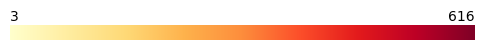

HTML(value='<pre style=\'font-family: monospace; white-space: pre-wrap;\'>&lt;manifest <span style="background…

In [13]:
without_results = influencial_values
del without_results['name']
del without_results['label']

VisualizeXML(EXAMPLE_CONTENT, without_results)

In [14]:
OBFUSCATED_EXAMPLE = """
<manifest xmlns:android="http://schemas.android.com/apk/res/android" android:versionCode="17" android:versionName="2.6">
  <uses-sdk android:minSdkVersion="15" android:targetSdkVersion="27"/>
  <uses-permission android:name="android.permission.READ_PHONE_STATE"/>
  <application android:theme="@android:0103000E" android:label="@7F0B001E" android:icon="@7F0A0002" android:name="com.stub.StubApp" android:allowBackup="true" android:supportsRtl="true" android:roundIcon="@7F0A0002">
    <activity android:name="com.yangzhizhe.geocal.MainActivity">
      <intent-filter>
        <action android:name="android.intent.action.MAIN"/>
        <category android:name="android.intent.category.LAUNCHER"/>
      </intent-filter>
    </activity>
  </application>
</manifest>
"""

In [15]:
DECEIVING_EXAMPLE = """
<manifest xmlns:android="http://schemas.android.com/apk/res/android" android:versionCode="17" package="fr.ubordeaux.math.yangzhizhe" android:versionName="2.6">
  <uses-sdk android:minSdkVersion="17" android:targetSdkVersion="27"/>
  <uses-permission android:name="android.permission.READ_PHONE_STATE"/>
  <application android:theme="@android:0103000E" android:label="@7F0B001E" android:icon="@7F0A0002" android:name="com.stub.StubApp" android:allowBackup="true" android:supportsRtl="true" android:roundIcon="@7F0A0002">
    <activity android:name="com.yangzhizhe.geocal.MainActivity">
      <intent-filter>
        <action android:name="android.intent.action.MAIN"/>
        <category android:name="android.intent.category.LAUNCHER"/>
      </intent-filter>
    </activity>
  </application>
</manifest>
"""

In [26]:
prediction = malbert_model.predict([EXAMPLE_CONTENT, OBFUSCATED_EXAMPLE, DECEIVING_EXAMPLE])

print(f"Prediction before obfuscation: {prediction[0][1]*100:.2f}% of being malware")
print(f"Prediction after obfuscation: {prediction[1][1]*100:.2f}% of being malware")
print(f"Model deceiving example: {prediction[2][1]*100:.2f}% of being malware")

1/1 [==============================] - 0s 401ms/step
Prediction before obfuscation: 91.24% of being malware
Prediction after obfuscation: 61.90% of being malware
Model deceiving example: 24.39% of being malware
